# Text-to-image generation with Qwen-Image and OpenVINO

Qwen-Image, an image generation foundation model in the Qwen series that achieves significant advances in complex text rendering and precise image editing. Experiments show strong general capabilities in both image generation and editing, with exceptional performance in text rendering, especially for Chinese. More details about model can be found in [blog post](https://qwenlm.github.io/blog/qwen-image/) and [model card](https://huggingface.co/Qwen/Qwen-Image).


<img src="https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-Image/merge3.jpg" width="1024"/>

In this tutorial we consider how to convert and optimize Qwen-Image model using OpenVINO.

>**Note**: Some demonstrated models can require at least 64GB RAM for conversion and running.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Select model](#Select-model)
- [Convert model with OpenVINO](#Convert-model-with-OpenVINO)
  - [Convert model using Optimum Intel](#Convert-model-using-Optimum-Intel)
  - [Compress model weights](#Compress-model-weights)
- [Run OpenVINO model inference](#Run-OpenVINO-model-inference)
- [Interactive demo](#Interactive-demo)



### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO and is using a custom branch of optimum-intel. It may be fully supported and validated in the future.

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/qwen-image/qwen-image.ipynb" />


## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [ ]:
import requests
from pathlib import Path

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/qwen-image/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

if not Path("pip_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py",
    )
    open("pip_helper.py", "w").write(r.text)

from pip_helper import pip_install

%pip uninstall -q -y diffusers optimum-intel

pip_install(
    "-q",
    "gradio>=4.19,<6",
    "torch>=2.1,<2.9",
    "transformers>=4.45,<4.58",
    "nncf>=2.15.0",
    "opencv-python",
    "pillow",
    "soxr==1.0.0",
    "peft>=0.15.0,<0.19",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)
pip_install("-q", "sentencepiece", "protobuf")
pip_install("-q", "diffusers>=0.35.0,<0.37")
pip_install("-q", "git+https://github.com/openvino-dev-samples/optimum-intel.git@qwen-image")
pip_install("-qU", "openvino>=2025.3")


# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("qwen-image.ipynb")

## Select model
[back to top ⬆️](#Table-of-contents:)

In [2]:
import ipywidgets as widgets

model_ids = ["Qwen/Qwen-Image-2512", "Qwen/Qwen-Image"]

model_selector = widgets.Dropdown(
    options=model_ids,
    default=model_ids[0],
    description="Model:",
)


model_selector

Dropdown(description='Model:', options=('Qwen/Qwen-Image-2512', 'Qwen/Qwen-Image'), value='Qwen/Qwen-Image-251…

## Convert model with OpenVINO
[back to top ⬆️](#Table-of-contents:)

Starting from 2023.0 release, OpenVINO supports PyTorch models directly via Model Conversion API. `ov.convert_model` function accepts instance of PyTorch model and example inputs for tracing and returns object of `ov.Model` class, ready to use or save on disk using `ov.save_model` function. 


The pipeline consists of four important parts:

* Text Encoders to create condition to generate an image from a text prompt.
* Transformer for step-by-step denoising latent image representation.
* Autoencoder (VAE) for encoding and decoding image.
  
### Convert model using Optimum Intel
[back to top ⬆️](#Table-of-contents:)

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. Fro int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used for  weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).

### Compress model weights
[back to top ⬆️](#Table-of-contents:)

For reducing model memory consumption we will use weights compression. The [Weights Compression](https://docs.openvino.ai/2024/openvino-workflow/model-optimization-guide/weight-compression.html) algorithm is aimed at compressing the weights of the models and can be used to optimize the model footprint and performance of large models where the size of weights is relatively larger than the size of activations, for example, Large Language Models (LLM). Compared to INT8 compression, INT4 compression improves performance even more, but introduces a minor drop in prediction quality. We will use [NNCF](https://github.com/openvinotoolkit/nncf) integration to `optimum-cli` tool for weight compression.

### Use optimized models provided on HuggingFace Hub
[back to top ⬆️](#Table-of-contents:)

For quick start, OpenVINO provides [collection](https://huggingface.co/collections/OpenVINO/image-generation-67697d9952fb1eee4a252aa8) of optimized models that are ready to use with OpenVINO GenAI. You can download them using following command:

```bash
huggingface-cli download <model_id> --local-dir <output_dir>
```


In [3]:
to_compress = widgets.Checkbox(
    value=True,
    description="Weight compression",
    disabled=False,
)

visible_widgets = [to_compress]

options = widgets.VBox(visible_widgets)

options

>**Note**: Weight compression will impact the quality of the generated image.

In [ ]:
from pathlib import Path

model_id = model_selector.value

model_base_dir = Path(model_id.split("/")[-1])
additional_args = {}

if to_compress.value:
    model_dir = model_base_dir / "INT8"
    additional_args.update({"weight-format": "int8"})
else:
    model_dir = model_base_dir / "FP16"
    additional_args.update({"weight-format": "fp16"})

In [5]:
from cmd_helper import optimum_cli

if not model_dir.exists():
    optimum_cli(model_id, model_dir, additional_args=additional_args)

## Run Optimum-intel model inference
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO.

In [6]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

In [7]:
import ipywidgets as widgets

model_available = (model_base_dir / "INT8").is_dir()
use_quantized_models = widgets.Checkbox(
    value=model_available,
    description="Use compressed models",
    disabled=not model_available,
)

use_quantized_models

Checkbox(value=True, description='Use compressed models')

OpenVINO integration with Optimum Intel provides ready-to-use API for model inference that can be used for smooth integration with transformers-based solutions. For loading Qwen-Image model, we will use `OVQwenImagePipeline` class that have compatible interface with Diffusers `OVQwenImagePipeline` implementation. For loading a model, `from_pretrained` method should be used. It accepts path to the model directory or model_id from HuggingFace hub (if model is not converted to OpenVINO format, conversion will be triggered automatically). Additionally, we can provide an inference device, quantization config (if model has not been quantized yet) and device-specific OpenVINO Runtime configuration. More details about model inference with Optimum Intel can be found in [documentation](https://huggingface.co/docs/optimum/intel/openvino/inference).

In [8]:
from optimum.intel import OVQwenImagePipeline

model_dir = model_base_dir / "INT8" if use_quantized_models.value else model_base_dir / "FP16"

ov_pipe = OVQwenImagePipeline.from_pretrained(model_dir, device=device.value)

Multiple distributions found for package optimum. Picked distribution: optimum-intel
/home2/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Now, you can define a text prompt and other pipeline settings for image generation and run inference pipeline.

  0%|          | 0/50 [00:00<?, ?it/s]

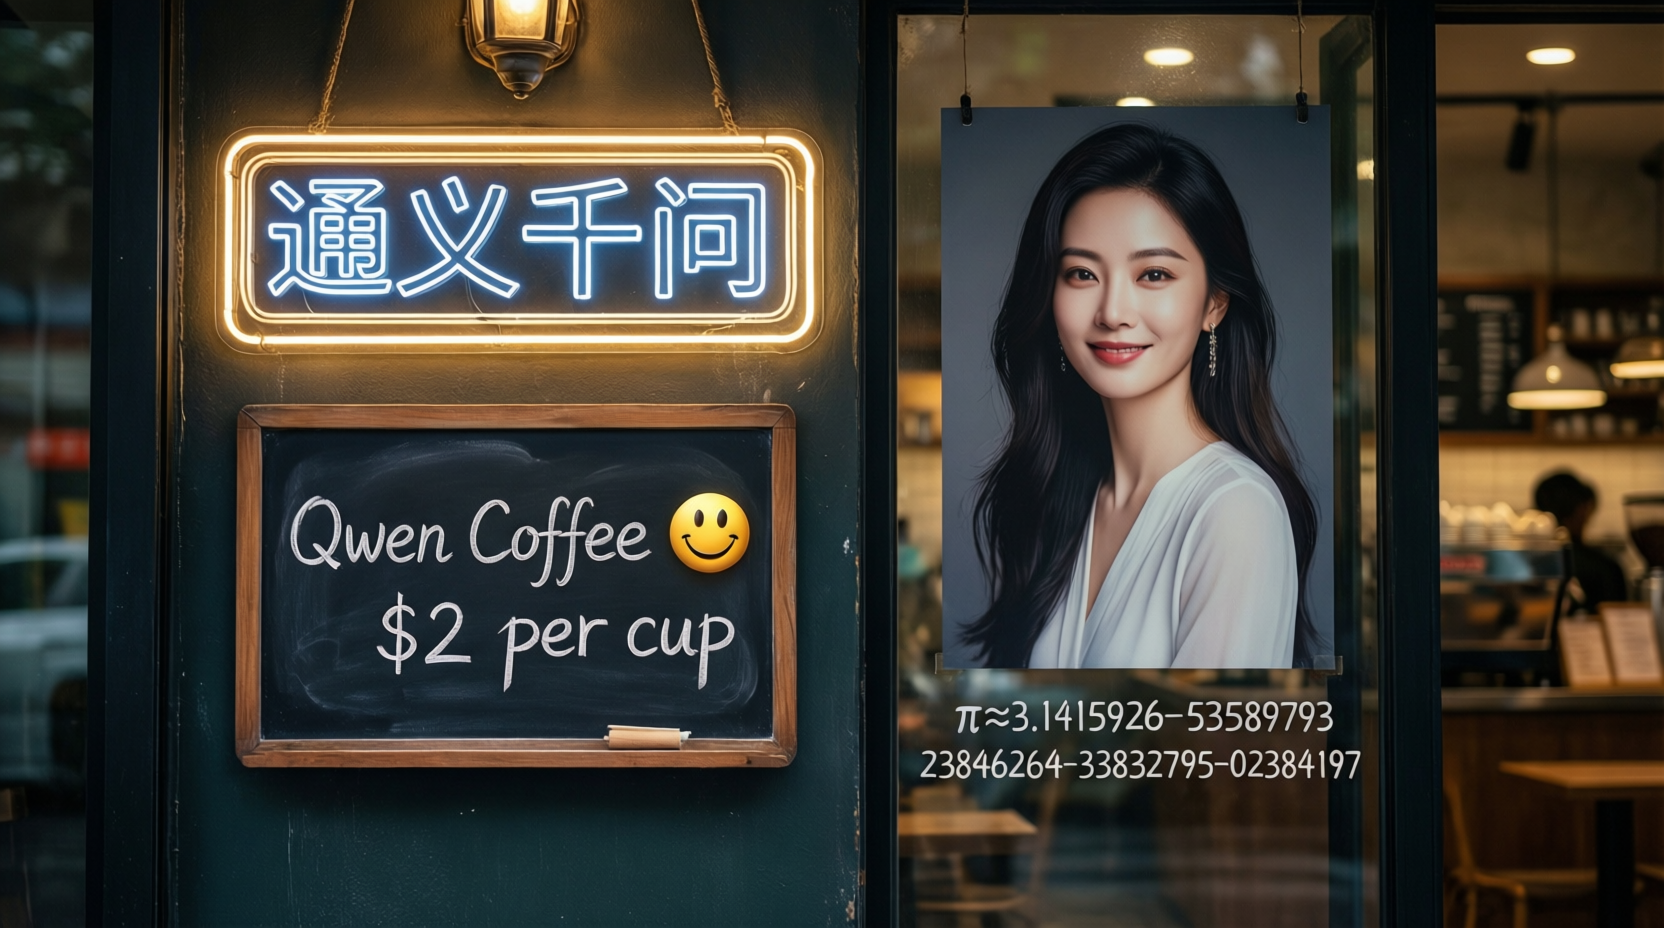

In [9]:
import torch

positive_magic = {"en": ", Ultra HD, 4K, cinematic composition.", "zh": ", 超清，4K，电影级构图."}  # for english prompt  # for chinese prompt

# Generate image
prompt = """A coffee shop entrance features a chalkboard sign reading "Qwen Coffee 😊 $2 per cup," with a neon light beside it displaying "通义千问". Next to it hangs a poster showing a beautiful Chinese woman, and beneath the poster is written "π≈3.1415926-53589793-23846264-33832795-02384197". Ultra HD, 4K, cinematic composition"""

negative_prompt = " "  # using an empty string if you do not have specific concept to remove


# Generate with different aspect ratios
aspect_ratios = {
    "1:1": (1328, 1328),
    "16:9": (1664, 928),
    "9:16": (928, 1664),
    "4:3": (1472, 1140),
    "3:4": (1140, 1472),
    "3:2": (1584, 1056),
    "2:3": (1056, 1584),
}

width, height = aspect_ratios["16:9"]

image = ov_pipe(
    prompt=prompt + positive_magic["en"],
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    num_inference_steps=50,
    true_cfg_scale=4.0,
    generator=torch.Generator(device="cpu").manual_seed(42),
).images[0]

image

In [ ]:
output_path = "generated_image.png"
image.save(output_path)
print(f"Saved image to {output_path}")

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [ ]:
from gradio_helper import make_demo

demo = make_demo(ov_pipe)

# if you are launching remotely, specify server_name and server_port
#  demo.launch(server_name='your server name', server_port='server port in int')
# if you have any issue to launch on your platform, you can pass share=True to launch method:
# demo.launch(share=True)
# it creates a publicly shareable link for the interface. Read more in the docs: https://gradio.app/docs/
try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)